In [ ]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [17]:
class BMI(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    category:str

In [18]:
def calculate(state:BMI)->BMI:
    weight=state["weight_kg"]
    height=state["height_m"]
    bmi=weight/(height**2)
    state["bmi"]=round(bmi,2)
    return state
    
def label(state:BMI)->BMI:
    bmi=state["bmi"]
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"
    return state

In [21]:
graph=StateGraph(BMI)


graph.add_node("label" ,label)
graph.add_node("calculate" ,calculate)
graph.add_edge(START,"calculate")
graph.add_edge("calculate","label")
graph.add_edge("label",END)

wf=graph.compile()

In [22]:
initial_state={"weight_kg":80,"height_m":4}
final=wf.invoke(initial_state)
print(final)

{'weight_kg': 80, 'height_m': 4, 'bmi': 5.0, 'category': 'Underweight'}


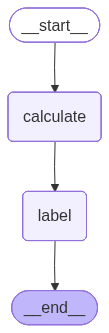

In [23]:
from IPython.display import Image, display

display(Image(wf.get_graph().draw_mermaid_png()))